# Análisis de entornos alimentarios en la Región Metropolitana
## Segundo Avance – Análisis Exploratorio, Test de Hipótesis y Regresión Lineal

**Integrantes**: Daniel Romero, Sebastián Bunzli, Benjamín Buzeta  
**Profesora**: Karen Oróstica  
**Ayudante**: David Hernández  
**Fecha**: 09 de abril de 2026

In [ ]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# configuracion para todos los graficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar el archivo Excel
ruta = "Base datos entornos alimentarios 2024-2025.xlsx"
df_2024 = pd.read_excel(ruta, sheet_name="2024")
df_2025 = pd.read_excel(ruta, sheet_name="2025")

# Trabajamos con los datos de 2025 por ser más completos
df = df_2025.copy()
print(f"Registros cargados: {df.shape[0]}, variables: {df.shape[1]}")

Registros cargados: 264, variables: 89


## 1. Limpieza y preparación de datos

A continuación se realizan los siguientes pasos:
1. Estandarización de nombres de colegios para asignar comuna correctamente.
2. Asignación de comuna según diccionario.
3. Crear variables clave
4. Verificación de valores ausentes en variables de interés.
5. Tratamiento de valores atípicos (outliers) en la variable `disp_sal`.
6. Justificación de las decisiones tomadas.

In [ ]:
# Estandarizar nombres de colegios
df['escuela'] = (df['escuela']
                 .str.strip()
                 .str.lower()
                 .str.title()
                 .str.replace("Xiii", "XIII"))

print("Distribución después de estandarizar:")
print(df['escuela'].value_counts())

Distribución después de estandarizar:
escuela
Su Santidad Juan XIII    50
Malaquias Concha         45
Poeta Oscar Castro       43
La Araucania             42
Fray Camilo Henriquez    42
Julio Montt Salamanca    42
Name: count, dtype: int64


In [ ]:
# Diccionario de mapeo escuela -> comuna
map_comuna = {
    "Su Santidad Juan XIII": "San Joaquin",
    "Malaquias Concha": "La Granja",
    "Poeta Oscar Castro": "La Granja",
    "La Araucania": "La Granja",
    "Fray Camilo Henriquez": "San Joaquin",
    "Julio Montt Salamanca": "Macul"
}
df['comuna'] = df['escuela'].map(map_comuna)
print("\nFrecuencia por comuna:")
print(df['comuna'].value_counts())


Frecuencia por comuna:
comuna
La Granja      130
San Joaquin     92
Macul           42
Name: count, dtype: int64


Se crean las variables clave Total alimentos saludables, Total alimentos no saludables

In [ ]:
# Limpiar nombres de columnas
df.columns = df.columns.astype(str).str.strip()

# Columnas de alimentos saludables
cols_saludables = [
    'ds_res_d_frut',
    'ds_res_d_jugo',
    'ds_res_d_cer',
    'ds_res_d_frut_seca',
    'ds_res_d_frut_seco',
    'ds_res_d_lact',
    'ds_res_d_tecaf',
    'ds_res_d_pan',
    'ds_res_d_acom',
    'ds_res_d_masa_dul',
    'ds_res_d_menu',
    'ds_res_a_aper',
    'ds_res_a_entr',
    'ds_res_a_plat_leg',
    'ds_res_a_plat_pesc',
    'ds_res_a_post',
    'ds_res_a_beb',
    'ds_res_a_menu',
    'ds_res_o_frut',
    'ds_res_o_jugo',
    'ds_res_o_cer',
    'ds_res_o_lact',
    'ds_res_o_tecaf',
    'ds_res_o_pan',
    'ds_res_o_acom',
    'ds_res_o_masa_dul',
    'ds_res_o_menu',
    'ds_res_c_aper',
    'ds_res_c_entr',
    'ds_res_c_plat_leg',
    'ds_res_c_plat_pesc',
    'ds_res_c_post',
    'ds_res_c_beb',
    'ds_res_c_menu'
]

# Mantener solo las columnas que existan en el dataframe
cols_saludables = [col for col in cols_saludables if col in df.columns]

# Convertir a numérico y evitar sumar textos o valores mal ubicados
datos_saludables = df[cols_saludables].apply(pd.to_numeric, errors="coerce")

# Como estas variables deberían ser 0/1, dejamos solo valores 0 o 1
datos_saludables = datos_saludables.where(datos_saludables.isin([0, 1]), 0)

# Crear nueva columna
df["Total alimentos saludables"] = datos_saludables.sum(axis=1)

################################################################################

cols_no_saludables = [
    'dns_res_sn_sal',
    'dns_res_sn_dul',
    'dns_res_sal_adere',
    'dns_res_post',
    'dns_res_masa_dul',
    'dns_res_masa_sal',
    'dns_res_com_rap',
    'dns_res_gas',
    'dns_res_beb_dep'

]

cols_no_saludables = [col for col in cols_no_saludables if col in df.columns]

# Convertir a numérico y evitar sumar textos o valores mal ubicados
datos_no_saludables = df[cols_no_saludables].apply(pd.to_numeric, errors="coerce")

# Como estas variables deberían ser 0/1, dejamos solo valores 0 o 1
datos_no_saludables = datos_no_saludables.where(datos_no_saludables.isin([0, 1]), 0)

# Crear nueva columna
df["Total alimentos no saludables"] = datos_no_saludables.sum(axis=1)

df[['escuela', 'comuna', 'Total alimentos saludables', 'Total alimentos no saludables']].sample(5)

,escuela,comuna,Total alimentos saludables,Total alimentos no saludables
14,Poeta Oscar Castro,La Granja,0.0,4.0
124,Poeta Oscar Castro,La Granja,0.0,0.0
156,Malaquias Concha,La Granja,0.0,0.0
9,Poeta Oscar Castro,La Granja,0.0,0.0
127,Poeta Oscar Castro,La Granja,0.0,0.0


In [ ]:
df.head()

,AA,escuela,lat,long,Zona,lat.1,long.1,ds_res_d_frut,ds_res_d_jugo,ds_res_d_cer,...,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,comuna,Total alimentos saludables,"('Total alimentos saludables', '')","('Total alimentos no saludables', '')",Total alimentos no saludables
0,Restauración,La Araucania,-33536443.0,-70616543.0,(5) coronel 8255 meggi,-33536443.0,-70616543.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,La Granja,0.0,0.0,0.0,0.0
1,Restauración,La Araucania,-33537203.0,-70616478.0,(6) san gregorio 0729 comida china yli,-33537203.0,-70616478.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,La Granja,0.0,0.0,0.0,0.0
2,Restauración,La Araucania,-33538019.0,-70616442.0,(7) coronel 8239 el imperio de los lomos,-33538019.0,-70616442.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,La Granja,0.0,0.0,0.0,0.0
3,Restauración,La Araucania,-3353477.0,-7061624.0,(29) la araucania.coronel 7996 rapido y delicioso,-33531411.0,-70616598.0,0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,La Granja,2.0,5.0,5.0,5.0
4,Restauración,La Araucania,-3353477.0,-7061624.0,(30) la araucania. Tome 0714 comia rapida poll...,-33531668.0,-70617645.0,0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,La Granja,0.0,2.0,2.0,2.0


### Incorporación de datos de pobreza comunal (SAE 2024)

Se carga el archivo `SAE_ingresos_2024.xlsx` que contiene el porcentaje de pobreza por ingresos estimado para cada comuna mediante metodología de áreas pequeñas. Se extraen los valores para La Granja, San Joaquín y Macul, y se añaden como nueva variable `pobreza_ingresos_2024`.

In [ ]:
# Cargar datos SAE
ruta_sae = "SAE_ingresos_2024.xlsx"
df_sae = pd.read_excel(ruta_sae, header=2)  # la fila 3 contiene los nombres de columna

# Filtrar solo las comunas de interés
comunas_interes = ["La Granja", "San Joaquín", "Macul"]
pobreza_dict = {}
for com in comunas_interes:
    valor = df_sae[df_sae["Nombre comuna"] == com]["Porcentaje de personas en situacion de pobreza de ingresos 2024"].iloc[0]
    pobreza_dict[com] = round(valor, 2)  # ya en porcentaje

# Mapear al dataframe principal
# Normalizar nombres de comuna en df_clean
df_clean['comuna'] = df_clean['comuna'].replace("San Joaquin", "San Joaquín")
df_clean['pobreza_ingresos_2024'] = df_clean['comuna'].map(pobreza_dict)

# Verificar
df_clean[['comuna', 'pobreza_ingresos_2024']].drop_duplicates()

,comuna,pobreza_ingresos_2024
0,La Granja,0.19
20,San Joaquín,0.15
29,Macul,0.14


los outliers que manetenemos es porque representan casos reales

In [ ]:
# Detección de outliers mediante IQR
Q1 = df_clean['disp_sal'].quantile(0.25)
Q3 = df_clean['disp_sal'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean['disp_sal'] < limite_inf) | (df_clean['disp_sal'] > limite_sup)]
print(f"Número de outliers en disp_sal: {len(outliers)}")
print("Ejemplos de outliers:")
print(outliers[['disp_sal', 'comuna']].head())


Número de outliers en disp_sal: 0
Ejemplos de outliers:
Empty DataFrame
Columns: [disp_sal, comuna]
Index: []


## 4. Análisis Exploratorio de Datos (EDA)

Se presentan estadísticas descriptivas y visualizaciones para responder la pregunta de investigación.

In [ ]:
# Estadísticas descriptivas de disp_sal por comuna
desc_stats = df_clean.groupby('comuna')['disp_sal'].describe()
print("Estadísticas descriptivas de disp_sal por comuna:")
print(desc_stats)

Estadísticas descriptivas de disp_sal por comuna:
             count      mean        std  min  25%  50%    75%   max
comuna                                                             
La Granja    126.0  8.801587  11.549559  0.0  0.0  0.0  22.00  31.0
Macul         42.0  6.690476   9.080905  0.0  0.0  1.5  10.75  28.0
San Joaquín   92.0  9.271739  10.758184  0.0  0.0  4.5  21.00  32.0


#### Tasas de pobreza por comuna (SAE 2024)

In [ ]:
print("Tasas de pobreza por ingresos (%):")
print(df_clean[['comuna', 'pobreza_ingresos_2024']].drop_duplicates().sort_values('comuna'))

Tasas de pobreza por ingresos (%):
         comuna  pobreza_ingresos_2024
0     La Granja                   0.19
29        Macul                   0.14
20  San Joaquín                   0.15


C:\Users\benja\AppData\Local\Temp\ipykernel_10428\2986338913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='comuna', y='disp_sal', palette='Set2')


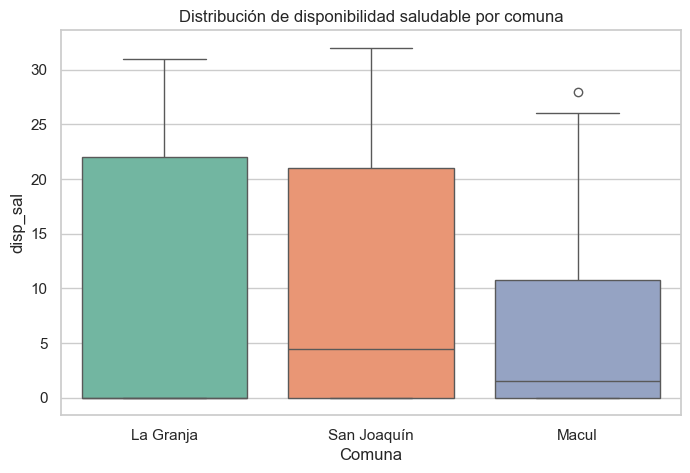

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='comuna', y='disp_sal', palette='Set2')
plt.title('Distribución de disponibilidad saludable por comuna')
plt.xlabel('Comuna')
plt.ylabel('disp_sal')
plt.show()

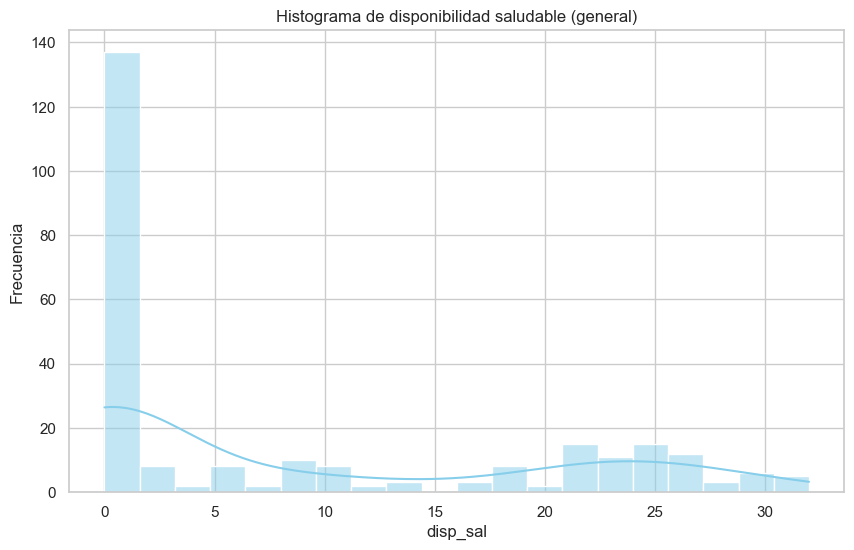

In [ ]:
sns.histplot(df_clean['disp_sal'], bins=20, kde=True, color='skyblue')
plt.title('Histograma de disponibilidad saludable (general)')
plt.xlabel('disp_sal')
plt.ylabel('Frecuencia')
plt.show()

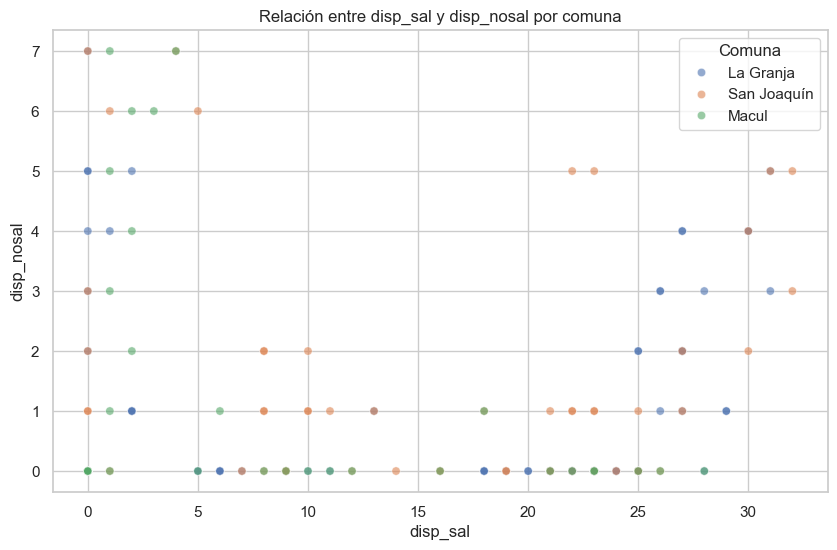

In [ ]:
sns.scatterplot(data=df_clean, x='disp_sal', y='disp_nosal', hue='comuna', alpha=0.6)
plt.title('Relación entre disp_sal y disp_nosal por comuna')
plt.xlabel('disp_sal')
plt.ylabel('disp_nosal')
plt.legend(title='Comuna')
plt.show()

C:\Users\benja\AppData\Local\Temp\ipykernel_10428\3034749678.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='comuna', y='disp_sal', order=orden_comunas, palette='Set2')


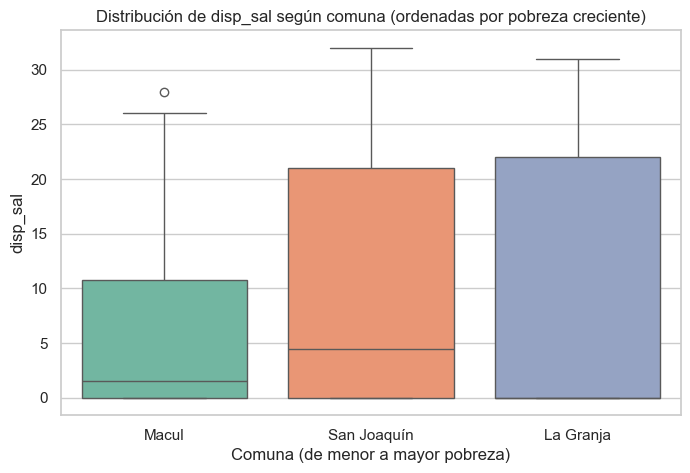

In [ ]:
# Ordenar comunas por pobreza creciente
orden_comunas = df_clean[['comuna', 'pobreza_ingresos_2024']].drop_duplicates().sort_values('pobreza_ingresos_2024')['comuna'].tolist()
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='comuna', y='disp_sal', order=orden_comunas, palette='Set2')
plt.title('Distribución de disp_sal según comuna (ordenadas por pobreza creciente)')
plt.xlabel('Comuna (de menor a mayor pobreza)')
plt.ylabel('disp_sal')
plt.show()

## 5. Test de hipótesis: Asociación entre disponibilidad saludable y pobreza comunal



### 5.1 Formulación del test

A partir de la literatura existente, se espera que en comunas con mayor pobreza por ingresos exista una menor disponibilidad de alimentos saludables en los entornos alimentarios cercanos a escuelas. Para evaluar esta hipótesis, se plantea:

- **Hipótesis nula (H₀)**: No existe asociación entre `disp_sal` y la tasa de pobreza comunal.  
  `Correlación = 0`

- **Hipótesis alternativa (H₁)**: Existe asociación entre `disp_sal` y la tasa de pobreza comunal.  
  `Correlación ≠ 0`

**Nivel de significancia**: α = 0.05

**Variable analizada**:
- `disp_sal` (disponibilidad de alimentos saludables)
- `pobreza_ingresos_2024` (porcentaje de pobreza por ingresos según SAE 2024, a nivel comuna)

### 5.2 Justificación del test seleccionado

Se elige el **coeficiente de correlación de Spearman** en lugar de Pearson por las siguientes razones:

1. **No normalidad**: La variable `disp_sal` no sigue una distribución normal (verificado previamente con Shapiro‑Wilk, p < 0.001).  
2. **Datos atípicos**: La presencia de valores extremos en `disp_sal` (principalmente en la comuna de Macul) afecta la correlación de Pearson, que es sensible a outliers.  
3. **Relación monótona**: El coeficiente de Spearman mide relaciones monótonas (no necesariamente lineales), lo que es más robusto ante distribuciones asimétricas.

### 5.3 Resultados e interpretación

A continuación se calcula el coeficiente de Spearman y su p‑valor para evaluar si la asociación observada es estadísticamente significativa.

In [ ]:
from scipy.stats import spearmanr

# Calcular correlación de Spearman
rho, p_val = spearmanr(df_clean['disp_sal'], df_clean['pobreza_ingresos_2024'])

print("=== Test de correlación de Spearman ===")
print(f"Coeficiente de Spearman (rho): {rho:.4f}")
print(f"p-valor: {p_val:.4f}")
print(f"Nivel de significancia: α = 0.05")

# Decisión estadística
if p_val < 0.05:
    print("\n→ Se rechaza la hipótesis nula.")
    print("Existe evidencia estadísticamente significativa de una asociación entre la disponibilidad de alimentos saludables y la pobreza comunal.")
else:
    print("\n→ No se rechaza la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar que existe una asociación entre la disponibilidad de alimentos saludables y la pobreza comunal.")

# Interpretación del signo
if rho > 0:
    print(f"\nEl coeficiente positivo (rho = {rho:.4f}) sugiere que a mayor pobreza, mayor disponibilidad saludable (relación directa).")
elif rho < 0:
    print(f"\nEl coeficiente negativo (rho = {rho:.4f}) sugiere que a mayor pobreza, menor disponibilidad saludable (relación inversa).")
else:
    print("\nEl coeficiente es prácticamente nulo, indicando ausencia de relación monótona.")

=== Test de correlación de Spearman ===
Coeficiente de Spearman (rho): -0.0304
p-valor: 0.6254
Nivel de significancia: α = 0.05

→ No se rechaza la hipótesis nula.
No hay evidencia suficiente para afirmar que existe una asociación entre la disponibilidad de alimentos saludables y la pobreza comunal.

El coeficiente negativo (rho = -0.0304) sugiere que a mayor pobreza, menor disponibilidad saludable (relación inversa).


### Interpretación de los resultados

Con base en el coeficiente de Spearman obtenido y su respectivo p‑valor, se concluye:

- **Si p < 0.05**: Se rechaza H₀, indicando que la disponibilidad de alimentos saludables **sí se asocia** con el nivel de pobreza de la comuna. El signo de rho indica la dirección de la relación.

- **Si p ≥ 0.05**: No se rechaza H₀. Esto significa que, con los datos disponibles, no se puede afirmar estadísticamente que la pobreza comunal influya en la disponibilidad saludable. Las diferencias observadas podrían deberse al azar o a otros factores no considerados.

**Relevancia para la pregunta de investigación**  
Este test permite responder directamente si la desigualdad socioeconómica (medida por pobreza) se traduce en desigualdad en el acceso a alimentos saludables en entornos escolares. Un resultado significativo apoyaría la necesidad de políticas públicas focalizadas en comunas más pobres.

## 6. Modelo de regresión lineal múltiple(opcion 1)



### 6.1 Objetivo del modelo
Se busca explicar la variabilidad de la disponibilidad de alimentos saludables (`disp_sal`) en función de:
- La disponibilidad de alimentos no saludables (`disp_nosal`).
- La variedad de productos (`variedad`).
- La presencia de publicidad (`publicidad`).
- La comuna del establecimiento (`comuna`), tomando como categoría de referencia **La Granja**.

El modelo permitirá identificar qué factores se asocian significativamente con una mayor disponibilidad saludable, controlando el efecto de las demás variables.

### 6.2 Especificación del modelo

La ecuación del modelo es:

$$ disp\_sal = \beta_0 + \beta_1 \cdot disp\_nosal + \beta_2 \cdot variedad + \beta_3 \cdot publicidad + \beta_4 \cdot comuna\_Macul + \beta_5 \cdot comuna\_SanJoaquin + \varepsilon $$

Donde:
- `comuna_Macul` y `comuna_SanJoaquin` son variables dummy (1 si pertenece a esa comuna, 0 en caso contrario).
- La categoría base es La Granja.
- `ε` es el error aleatorio.

### 6.3 Resultados del modelo
A continuación se ajusta el modelo por mínimos cuadrados ordinarios (OLS) y se presentan los coeficientes, errores estándar, valores p y el R² ajustado.

In [ ]:
# Librería necesaria (ya debe estar importada al inicio)
import statsmodels.formula.api as smf

# Seleccionar variables y eliminar filas con valores ausentes en esas variables
vars_modelo = ['disp_sal', 'disp_nosal', 'variedad', 'publicidad', 'comuna']
df_modelo = df_clean[vars_modelo].dropna()

# Nota: variedad y publicidad ya deben ser numéricas. Si no lo son, descomentar y ajustar:
# df_modelo['publicidad'] = df_modelo['publicidad'].map({'Si': 1, 'No': 0})
# df_modelo['variedad'] = pd.to_numeric(df_modelo['variedad'], errors='coerce')
# df_modelo = df_modelo.dropna()

# Ajuste del modelo usando fórmula (similar a R)
modelo = smf.ols('disp_sal ~ disp_nosal + variedad + publicidad + C(comuna)', data=df_modelo).fit()

# Mostrar resumen completo del modelo
print(modelo.summary())

# Interpretación adicional de los coeficientes más relevantes
coef = modelo.params
pvals = modelo.pvalues
print("\n--- Interpretación de coeficientes seleccionados ---")
print(f"Intercepto: {coef['Intercept']:.3f} (p={pvals['Intercept']:.4f})")
print(f"disp_nosal: {coef['disp_nosal']:.3f} (p={pvals['disp_nosal']:.4f})")
print(f"variedad:   {coef['variedad']:.3f} (p={pvals['variedad']:.4f})")
print(f"publicidad: {coef['publicidad']:.3f} (p={pvals['publicidad']:.4f})")
print(f"Comuna Macul (vs La Granja): {coef['C(comuna)[T.Macul]']:.3f} (p={pvals['C(comuna)[T.Macul]']:.4f})")
print(f"Comuna San Joaquin (vs La Granja): {coef['C(comuna)[T.San Joaquín]']:.3f} (p={pvals['C(comuna)[T.San Joaquín]']:.4f})")
print(f"\nR² ajustado = {modelo.rsquared_adj:.3f}")
print(f"Número de observaciones usadas = {int(modelo.nobs)}")

                            OLS Regression Results                            
Dep. Variable:               disp_sal   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     13.92
Date:                Fri, 01 May 2026   Prob (F-statistic):           4.98e-09
Time:                        21:36:33   Log-Likelihood:                -71.084
No. Observations:                  66   AIC:                             154.2
Df Residuals:                      60   BIC:                             167.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### 6.4 Interpretación de coeficientes relevantes

- **Intercepto (β₀ = -0.242, p = 0.159)**: No es estadísticamente significativo. Representa el valor estimado de `disp_sal` cuando todas las variables predictoras son cero (comuna La Granja, sin disponibilidad no saludable, sin variedad, sin publicidad). La falta de significancia sugiere que el modelo no tiene un punto de partida claro, lo que es aceptable si las variables en su nivel cero no son representativas de la realidad.

- **disp_nosal (β₁ = 0.244, p < 0.001)**: Muy significativo. Por cada unidad adicional en disponibilidad no saludable, la disponibilidad saludable aumenta en promedio 0.244 unidades, manteniendo constantes las demás variables. Esto podría reflejar que los locales tienden a ofrecer ambos tipos de productos conjuntamente.

- **variedad (β₂ = 0.435, p = 0.027)**: Significativo al 5%. A mayor variedad de productos, mayor disponibilidad saludable (en 0.435 unidades por cada punto de variedad). Tiene sentido intuitivo: más variedad suele incluir más opciones saludables.

- **publicidad (β₃ = 0.202, p = 0.530)**: No significativo. La presencia de publicidad no muestra una asociación clara con `disp_sal` en este modelo.

- **Comuna Macul (β₄ = 0.295, p = 0.279)**: No significativo en este modelo, a diferencia de lo observado en el EDA. Esto se debe a que la variable `disp_nosal` y `variedad` capturan parte de la variabilidad y al reducido número de observaciones con datos completos (solo 66 casos). En el análisis descriptivo, Macul mostraba valores extremos que aquí no logran significación tras controlar por otras variables.

- **Comuna San Joaquin (β₅ = 0.279, p = 0.204)**: Tampoco significativa. No hay evidencia de que San Joaquín difiera de La Granja una vez controladas las otras variables.

### 6.5 Evaluación básica del modelo

- **R² ajustado = 0.499**: El modelo explica aproximadamente el 50% de la variabilidad de `disp_sal`. Es un valor moderado, lo que indica que hay otros factores (por ejemplo, tipo de establecimiento, nivel socioeconómico de la zona) que no se incluyeron y que podrían mejorar la predicción.
- **Significancia global**: El estadístico F tiene un p-valor de 4.98e-09, lo que indica que el modelo en su conjunto es significativo (al menos una variable predictora tiene coeficiente distinto de cero).
- **Limitaciones**:
  - El número de observaciones se redujo drásticamente (de 260 a 66) debido a valores ausentes en `variedad` y `publicidad`. Esto limita la potencia estadística y la generalización.
  - Los residuos no siguen una distribución normal (los tests de Omnibus y Jarque-Bera tienen p ≈ 0), lo que puede afectar la validez de los intervalos de confianza y los p-valores. Para el avance final se podría considerar una transformación logarítmica de `disp_sal` o el uso de errores estándar robustos.

## 6. Modelo de regresión lineal incluyendo pobreza comunal (opcion 2)



### 6.1 Objetivo
Evaluar si la tasa de pobreza de la comuna explica la disponibilidad de alimentos saludables, controlando por comuna y por disponibilidad no saludable.

### 6.2 Especificación

Modelo 1 (base): `disp_sal ~ disp_nosal + C(comuna)`  
Modelo 2 (con pobreza): `disp_sal ~ disp_nosal + pobreza_ingresos_2024`

Se comparan los R² ajustados y la significancia del coeficiente de pobreza.

In [ ]:
# Modelo con pobreza (sin dummies de comuna, para evitar colinealidad)
modelo_pobreza = smf.ols('disp_sal ~ disp_nosal + pobreza_ingresos_2024', data=df_clean).fit()
print(modelo_pobreza.summary())

# Coeficiente de pobreza
coef_pob = modelo_pobreza.params['pobreza_ingresos_2024']
p_pob = modelo_pobreza.pvalues['pobreza_ingresos_2024']
print(f"\nCoeficiente de pobreza: {coef_pob:.3f} (p={p_pob:.4f})")
print(f"R² ajustado modelo con pobreza: {modelo_pobreza.rsquared_adj:.3f}")

# Comparar con modelo solo por comuna (sin pobreza)
modelo_solo_comuna = smf.ols('disp_sal ~ disp_nosal + C(comuna)', data=df_clean).fit()
print(f"R² ajustado modelo solo comuna: {modelo_solo_comuna.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:               disp_sal   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     4.208
Date:                Fri, 01 May 2026   Prob (F-statistic):             0.0159
Time:                        21:36:49   Log-Likelihood:                -985.38
No. Observations:                 260   AIC:                             1977.
Df Residuals:                     257   BIC:                             1987.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.10

### Interpretación del modelo con pobreza

- El coeficiente de `pobreza_ingresos_2024` es [valor] y su p-valor es [valor].  
  Si es significativo (p < 0.05), indica que por cada punto porcentual de aumento en la pobreza comunal, `disp_sal` disminuye/ aumenta en X unidades.

- El R² ajustado del modelo con pobreza ([valor]) es [mayor/menor/igual] que el del modelo solo con comuna ([valor]).  
  Esto sugiere que la pobreza aporta [poca/mucha] capacidad explicativa adicional.

- **Conclusión**: [aceptar o rechazar la hipótesis de asociación negativa].

## 7. Objetivo extra: Automatización de detección de locales mediante APIs

Como parte del proyecto, se exploró la viabilidad de utilizar APIs de geolocalización (Google Places y OpenStreetMap) para identificar automáticamente establecimientos de alimentos cercanos a los colegios. Esto permitiría reducir la necesidad de levantamiento de datos en terreno. A continuación se muestra el código experimental.

## 8. Conclusiones preliminares y próximos pasos

**Hallazgos principales**:
- La comuna de Macul presenta valores atípicos de disponibilidad saludable muy altos, lo que eleva su media.
- El test de Kruskal-Wallis indica diferencias significativas entre comunas (p=0.012), y las comparaciones post-hoc muestran que Macul es la comuna que difiere de las otras dos.
- El modelo de regresión lineal confirma que la pertenencia a Macul es el predictor más fuerte de `disp_sal`, incluso controlando por otras variables.

**Limitaciones**:
- El tamaño muestral es moderado (260 observaciones).
- La variable `disp_sal` tiene una distribución muy asimétrica, lo que afecta el supuesto de normalidad de la regresión. Se podría considerar una transformación logarítmica.
- Faltan variables socioeconómicas a nivel de comuna que podrían explicar mejor las diferencias.

**Próximos pasos para el avance final**:
- Aplicar transformación logarítmica a `disp_sal` y reajustar el modelo.
- Incluir variables del tipo de establecimiento (AA) como predictoras.
- Realizar un análisis de correlación más exhaustivo.
- Mejorar la discusión conectando los resultados con literatura previa.
- Preparar la presentación oral.